### Import Library

In [1]:
import os
import sys
repo_root = os.path.abspath(os.path.join(os.getcwd(),"../../.."))
sys.path.insert(0,repo_root)

In [2]:
from typing import Annotated, List,Optional
from langgraph.graph import StateGraph,add_messages,START,END
from pydantic import BaseModel,Field
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage,AIMessage
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

c:\Users\abhis\OneDrive\Learner\Github\Python\.py311_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from Gen_AI.config import db_directory

c:\Users\abhis\OneDrive\Learner\Github\Python\Gen_AI\projects\notebooks


In [4]:
load_dotenv()
LLM_SECRETS = os.getenv("GROQ_API")
llm = ChatGroq(model='llama-3.1-8b-instant',api_key = LLM_SECRETS)

### Develpoment

In [5]:
class State(BaseModel):
    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    rewritten_query: Optional[str] = None
    session_id: Optional[str] = None
    user_id: Optional[str] = None
    context: Optional[str] = None
    retrieved_docs: Optional[list] = None
    retrieved_history: Optional[list] = None
    human_summary: Optional[str] = None

#### 2.1. Creating LLM Long Term Memory

In [6]:
def deserialize_messages(retrieved_conversation):
    messages = []

    for msg in retrieved_conversation:
        if msg["type"] == "HumanMessage":
            messages.append(HumanMessage(content=msg["content"]))

        elif msg["type"] == "AIMessage":
            messages.append(AIMessage(content=msg["content"]))

    return messages

In [7]:
def load_memory(state:State):
    user_id = state.user_id
    session_id = state.session_id
    if not user_id or not session_id:
        file_path = file_path = "../llm_memory.json"
        with open(file_path,'r') as f:
            llm_memory = json.load(f)
        user_id = str(input('Enter your login profile'))
        if user_id in llm_memory: 
            print(f"===Available Session IDs===")
            for i,session_id in enumerate(list(llm_memory[user_id]['sessions'].keys()),1):
               print(f"{i}.{session_id}")
               session_id = print("0.New session")
            choice = int(input('Pick your session option:'))
            if choice==0:
                print("New Session requested!")
                return {
                    'user_id':user_id,
                    'session_id':str(uuid.uuid4())
                }
            session_id = list(llm_memory[user_id]['sessions'].keys())[choice-1]
               
            conversation = llm_memory[user_id]['sessions'][session_id]['conversation']
            retrieved_messages = deserialize_messages(conversation)
            retrieved_profile = llm_memory[user_id]['profile']['personality']
            return{
                'user_id':user_id,
                'session_id':session_id,
                'messages':retrieved_messages,
                'human_summary':retrieved_profile
            }
        else:
            print("User ID not found Creating New User!")
            return{
                'user_id':user_id,
                'session_id':str(uuid.uuid4())
            }

In [8]:
def serialize_messages(messages):
    return [
        {
            "type": msg.__class__.__name__,
            "content": msg.content
        }
        for msg in messages
    ]

In [9]:
def summaries_human_profile(state: State):
    print("==================== human summary called ==================")

    messages = state.messages[-12:]

    # Only human messages
    user_msgs = [
        msg.content for msg in messages
        if msg.__class__.__name__ == "HumanMessage"
    ]

    if len(user_msgs) < 6:
        return {
        "human_summary": None
    }

    conversation_context = "\n".join(user_msgs)

    prompt = f"""
                You are analyzing a USER.

                Task:
                Summarize:
                - communication style
                - tone
                - preferences

                Rules:
                - Only use provided messages
                - No assumptions
                - Max 4 lines

                Chat:
                {conversation_context}

                Summary:
                """

    response = llm.invoke(prompt)
    summary = response.content.strip()

    print(f"Summary: {summary}")

    return {
        "human_summary": summary
    }

In [10]:
import json
import os
import uuid

def save_memory(state: State):
    file_path = "../llm_memory.json"

    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            data = json.load(f)
    else:
        data = {}

    user_id = state.user_id or str(uuid.uuid4())
    session_id = state.session_id or str(uuid.uuid4())


    if user_id not in data:
        data[user_id] = {
            "profile": {},
            "sessions": {}
        }

    if state.human_summary:
        data[user_id]["profile"]["personality"] = state.human_summary

    data[user_id]["sessions"][session_id] = {
        "conversation": serialize_messages(state.messages)
    }

    with open(file_path, "w") as f:
        json.dump(data, f, indent=4)

    return {
        "user_id": user_id,
        "session_id": session_id
    }

#### 2.2. Building LLM Nodes and Tools

In [11]:
db_path = str(db_directory / 'text_data_vectors')
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vector_db = Chroma(persist_directory=db_path,
            embedding_function=embedding_model,
            collection_metadata={"hnsw:space":"cosine"})
docs_retriever = vector_db.as_retriever(search_kwargs = {"k":5})

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3209.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
def format_query(state: State):
    print("==================== format query Called ==================")

    messages = state.messages
    user_query = messages[-1].content

    # Take last few messages (excluding current)
    history = messages[-5:]

    history_text = "\n".join(
        f"{msg.__class__.__name__}: {msg.content}"
        for msg in history
    )

    print(f"User Query: {user_query}")
    print(f"History length: {len(history)}")

    prompt = f"""
        You are a query rewriting assistant.

        Task:
        - If the question depends on previous conversation → rewrite it into a standalone query with no past conversation dependency.
        - If the question is already standalone → return it EXACTLY as is.

        STRICT RULES:
        - Do NOT paraphrase standalone questions.
        - Do NOT add extra words.
        - Only return the final query.

        Chat History:
        {history_text}

        User Question:
        {user_query}

        Final Query:
        """

    response = llm.invoke(prompt)
    search_query = response.content.strip()

    print(f"Rewritten Query: {search_query}")

    return {
        "rewritten_query": search_query
    }

In [13]:
def retrieve_docs(state:State):
    print("==============Document retriever Called======================")
    message = state.rewritten_query
    print(f"Query Received by retriever: {message}")
    relevant_docs = docs_retriever.invoke(message)
    print(f"Documents retrieved from Rag: {len(relevant_docs)}")
    return {
        'retrieved_docs':relevant_docs
    }

In [14]:

def rag_llm(state: State):
    messages = state.messages[-10:]
    document_context = state.retrieved_docs
    combined_context = "\n\n".join(doc.page_content for doc in document_context)
    user_profile = state.human_summary
    print(f"Content Recieved from RAG {combined_context[:100]}")
    rag_prompt = [SystemMessage(content = "You are an AI Assistant trained on documents take the user tone, preferences into consideration when responding"),
            HumanMessage(content = f"""Question:
                            {messages}
                            Context: {combined_context}
                            User preferences: {user_profile}
                            respond to users query with response curated only from documents provided in context and rephrasing your response based on user preferences""")
                            ]
    response = llm.invoke(rag_prompt)

    return {
        'messages':[response]
    }

##### 2.3. Adding Short-term Memory to LangGraph as it is not automatically maintained by langGraph

In [15]:
memory = MemorySaver()

In [16]:
workflow = StateGraph(State)
workflow.add_node('load_memory',load_memory)
workflow.add_node('rewrite_query',format_query)
workflow.add_node('rag_retrieval',retrieve_docs)
workflow.add_node('llm_call',rag_llm)
workflow.add_node('summaries_human_profile',summaries_human_profile)
workflow.add_node('save_memory',save_memory)

workflow.add_edge(START,'load_memory')
workflow.add_edge('load_memory','rewrite_query')
workflow.add_edge('rewrite_query','rag_retrieval')
workflow.add_edge('rag_retrieval','llm_call')
workflow.add_edge('llm_call','summaries_human_profile')
workflow.add_edge('summaries_human_profile','save_memory')
workflow.add_edge('save_memory',END)
rag_app = workflow.compile(checkpointer=memory)

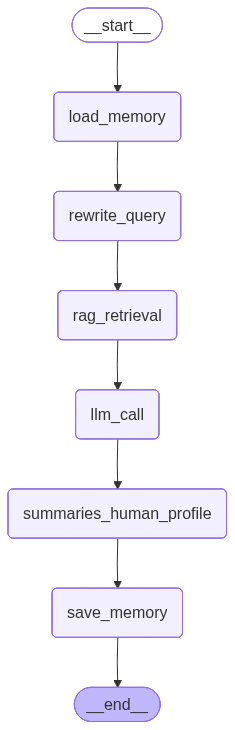

In [17]:
from IPython.display import Image, display
display(Image(rag_app.get_graph().draw_mermaid_png()))

In [18]:
session = {
    "configurable":{
        'thread_id':'user001'
    }
}

In [ ]:
while True:
    query = str(input("Type your message"))
    if query in ['bye','quit']:
        break
    else:
        response = rag_app.invoke({
            'messages': HumanMessage(content=query)
        },config=session)
        for msg in response['messages'][-2:]:
            msg.pretty_print()
# What can you tell me about github acquistion
# When did this acquistion happened?

===Available Session IDs===
1.8109d28f-00b3-4290-9127-771bd51c13f3
0.New session
==================== format query Called ==================
User Query: Based on the provided context and the user's preferences, here's a rephrased and curated response:

**User's Query:** What can you tell me about the preferences of the current user?

**Curated Response:**

Unfortunately, there is no information in the provided context about the current user's preferences. The context only includes information about Google's services, employees, and corporate structure, but does not mention anything about user preferences.

However, I can tell you that the user's query about DeepMind was responded to with information curated from the documents provided in the context, and the response was rephrased to meet the user's preferences.

If you would like to know more about the context or the user's preferences, please let me know and I will do my best to provide a helpful response.
History length: 5
Rewritten

In [20]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

hi
================================ Human Message =================================

hi
================================ Human Message =================================

71e13b14-c596-4c6f-aace-8f25116f6430
================================ Human Message =================================

Hi, How are you today?
================================ Human Message =================================

hi
================================ Human Message =================================

How are you?
================================ Human Message =================================

Hi
================================ Human Message =================================

Hey, When di Git hub Acquistion happpen?
================================== Ai Message ==================================

According to the provided context, the acquisition of GitHub by Microsoft occurred on June 4, 2018, and was officially announced on the 